# 56 — Firewall Decision Module: Evaluation & Visualization

**Project:** AI VPN Firewall — Thesis  
**Source pipeline:** Clean Pipeline (NB41-55)  
**Feature family:** safe_temporal_21 / direction_invariant_augmented (25 features)  
**Models:** XGBoost + LightGBM + CatBoost ensemble (mean score)  
**Datasets:** ISCX-VPN-2016, USBVPN-2021, VNAT-2024

---

## What this notebook does

1. **Core metrics** — ROC-AUC, PR-AUC, Brier score, ECE  
2. **Operating points** — FPR @ 99% precision, Recall @ FPR thresholds  
3. **Two-tier firewall simulation** — T_block / T_monitor thresholds  
4. **Zone analysis** — PASS / MONITOR / BLOCK with confusion breakdown  
5. **Per-dataset breakdown** — how the firewall performs on each dataset  
6. **ROC & PR curves** — with operating points marked  
7. **Score distributions** — benign vs VPN histograms with threshold lines  
8. **Calibration reliability diagram** — ECE visualization

## 0. Setup

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.eval.calibration_diagnostics import expected_calibration_error

# Paths
CLEAN   = ROOT / "artifacts" / "clean_pipeline"
EVAL    = ROOT / "artifacts" / "eval"
VAL_P   = CLEAN / "models" / "val_predictions.parquet"
TEST_P  = CLEAN / "models" / "test_predictions.parquet"
OP_JSON = EVAL / "firewall_operating_points.json"
OP_CSV  = EVAL / "firewall_operating_points.csv"
DS_CSV  = EVAL / "firewall_operating_points_per_dataset.csv"

# Load
val_df  = pd.read_parquet(VAL_P)
test_df = pd.read_parquet(TEST_P)

y_test = test_df["label"].values
p_test = test_df["ensemble_score"].values

with open(OP_JSON) as f:
    results = json.load(f)

op_table = pd.read_csv(OP_CSV)

print(f"Val:  {val_df.shape[0]:,} flows")
print(f"Test: {test_df.shape[0]:,} flows  (pos={y_test.sum():,}  neg={(y_test==0).sum():,})")
print(f"Datasets: {sorted(test_df['dataset'].unique())}")
print(f"Source: {results.get('source', 'unknown')}")

Val:  4,268 flows
Test: 4,256 flows  (pos=1,768  neg=2,488)
Datasets: ['iscx', 'usbvpn', 'vnat']
Source: clean_pipeline (NB41-55)


## 1. Core Metrics Summary

In [2]:
cm = results["core_metrics"]
metrics_df = pd.DataFrame([
    {"Metric": "ROC-AUC",   "Value": f'{cm["roc_auc"]:.4f}',   "Interpretation": "Excellent" if cm["roc_auc"] > 0.99 else "Good"},
    {"Metric": "PR-AUC",    "Value": f'{cm["pr_auc"]:.4f}',    "Interpretation": "Excellent" if cm["pr_auc"] > 0.99 else "Good"},
    {"Metric": "Brier",     "Value": f'{cm["brier"]:.4f}',     "Interpretation": "Low = better"},
    {"Metric": "ECE",       "Value": f'{cm["ece"]:.4f}',       "Interpretation": cm["calibration_quality"]},
    {"Metric": "Threshold stability risk", "Value": cm["threshold_stability_risk"], "Interpretation": ""},
])
display(metrics_df.style.set_caption("Core Classifier Metrics (Test Split)").hide(axis='index'))

Metric,Value,Interpretation
ROC-AUC,0.9955,Excellent
PR-AUC,0.9949,Excellent
Brier,0.0200,Low = better
ECE,0.0259,well-calibrated
Threshold stability risk,low,


## 2. Operating Points Table

In [3]:
display(op_table.style.set_caption("Firewall Operating Points").format(
    {"value": "{:.6f}", "threshold": "{}"},
    na_rep="—"
).hide(axis='index'))

metric,value,split,threshold,note
ROC-AUC,0.995485,test,—,area under ROC curve
PR-AUC,0.994851,test,—,area under precision-recall curve
Brier,0.020028,test,—,mean squared error of probabilities
ECE,0.025934,test,—,expected calibration error (15-bin)
FPR_at_99pct_precision,0.006431,test,0.5853891659576559,recall=0.9457
Recall_at_FPR_le_0.1pct,0.881787,test,0.8808187237797044,actual FPR=0.000804
Recall_at_FPR_le_1pct,0.953054,test,0.5518847862767045,actual FPR=0.009244
T_block,0.639245,val->test,0.6392446835839968,FPR target=0.0 on val
T_monitor,0.512222,val->test,0.5122219238238386,FPR target=0.01 on val
false_block_rate,0.005225,test,0.6392446835839968,FPR at T_block on test


## 3. ROC & Precision-Recall Curves

Operating points (T_block, T_monitor, FPR=0.1%, FPR=1%) marked on each curve.

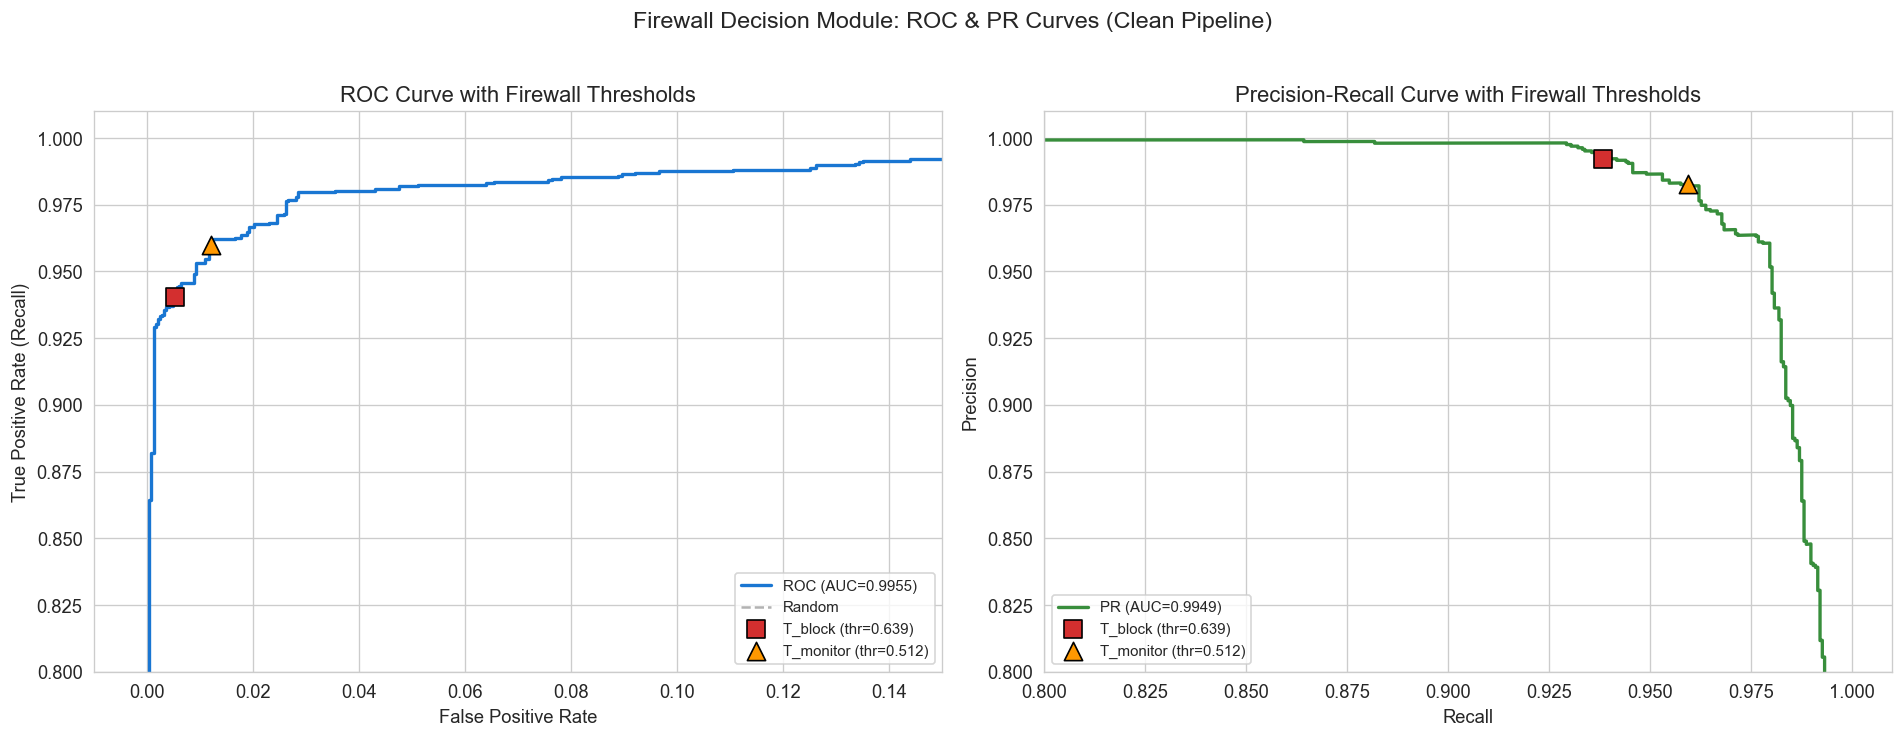

In [4]:
fw = results["firewall_thresholds"]
T_block   = fw["T_block"]
T_monitor = fw["T_monitor"]

fpr_arr, tpr_arr, roc_thr = roc_curve(y_test, p_test)
prec_arr, rec_arr, pr_thr = precision_recall_curve(y_test, p_test)

roc_auc_val = roc_auc_score(y_test, p_test)
pr_auc_val  = average_precision_score(y_test, p_test)

def find_point_on_roc(threshold):
    idx = np.searchsorted(-roc_thr, -threshold)
    idx = min(idx, len(fpr_arr)-1)
    return fpr_arr[idx], tpr_arr[idx]

def find_point_on_pr(threshold):
    idx = np.searchsorted(pr_thr, threshold)
    idx = min(idx, len(prec_arr)-1)
    return rec_arr[idx], prec_arr[idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- ROC ---
ax1.plot(fpr_arr, tpr_arr, color="#1976D2", linewidth=2, label=f"ROC (AUC={roc_auc_val:.4f})")
ax1.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")

markers = [
    (T_block,   "T_block",   "#D32F2F", "s"),
    (T_monitor, "T_monitor", "#FF9800", "^"),
]
for thr, name, color, marker in markers:
    fx, fy = find_point_on_roc(thr)
    ax1.scatter(fx, fy, c=color, s=120, zorder=5, marker=marker, edgecolors="black",
                label=f"{name} (thr={thr:.3f})")

ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate (Recall)")
ax1.set_title("ROC Curve with Firewall Thresholds")
ax1.legend(loc="lower right", fontsize=9)
ax1.set_xlim(-0.01, 0.15)
ax1.set_ylim(0.80, 1.01)

# --- PR ---
ax2.plot(rec_arr, prec_arr, color="#388E3C", linewidth=2, label=f"PR (AUC={pr_auc_val:.4f})")

for thr, name, color, marker in markers:
    rx, ry = find_point_on_pr(thr)
    ax2.scatter(rx, ry, c=color, s=120, zorder=5, marker=marker, edgecolors="black",
                label=f"{name} (thr={thr:.3f})")

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve with Firewall Thresholds")
ax2.legend(loc="lower left", fontsize=9)
ax2.set_xlim(0.80, 1.01)
ax2.set_ylim(0.80, 1.01)

plt.suptitle("Firewall Decision Module: ROC & PR Curves (Clean Pipeline)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Score Distributions with Firewall Zones

The background colors show the three firewall zones: PASS (green), MONITOR (yellow), BLOCK (red).

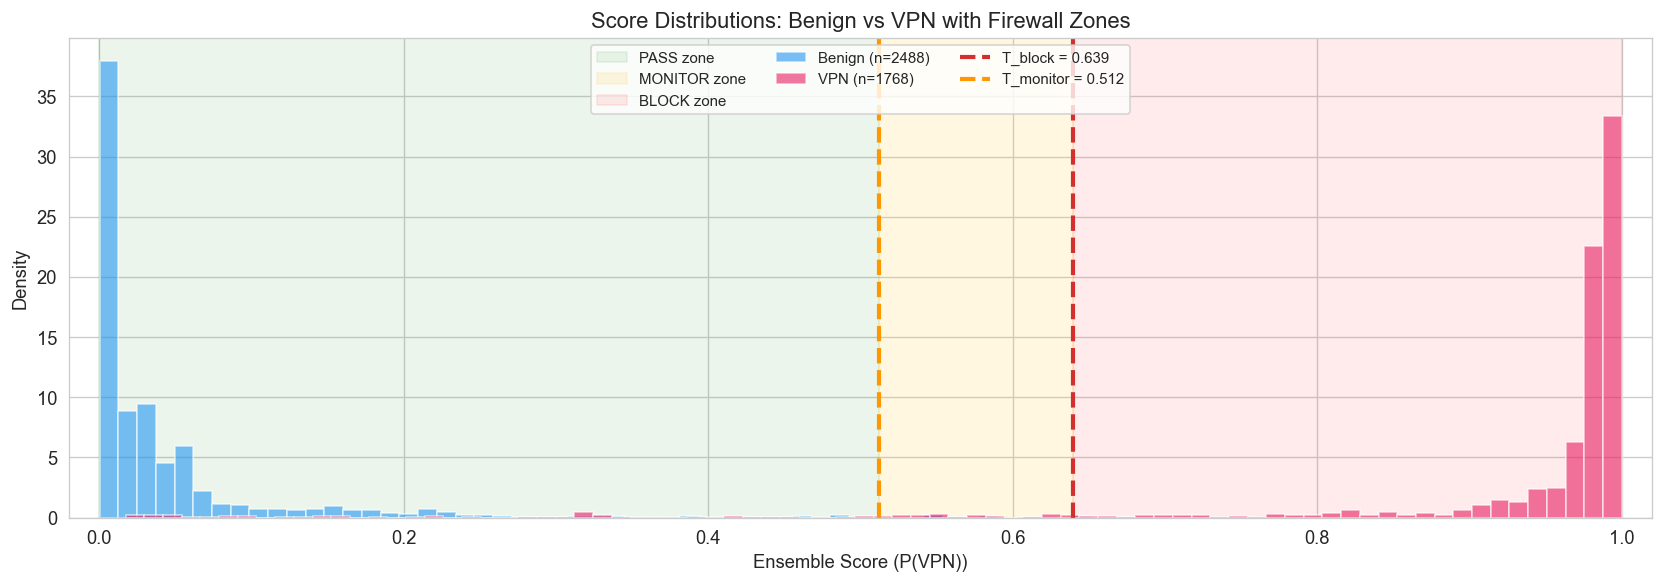

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

benign_scores = p_test[y_test == 0]
vpn_scores    = p_test[y_test == 1]

# Zone backgrounds
ax.axvspan(0, T_monitor, alpha=0.08, color="green", label="PASS zone")
ax.axvspan(T_monitor, T_block, alpha=0.12, color="#FFC107", label="MONITOR zone")
ax.axvspan(T_block, 1.0, alpha=0.08, color="red", label="BLOCK zone")

# Histograms
ax.hist(benign_scores, bins=80, alpha=0.6, density=True, color="#2196F3", label=f"Benign (n={len(benign_scores)})")
ax.hist(vpn_scores, bins=80, alpha=0.6, density=True, color="#E91E63", label=f"VPN (n={len(vpn_scores)})")

# Threshold lines
ax.axvline(T_block, color="#D32F2F", linestyle="--", linewidth=2.5, label=f"T_block = {T_block:.3f}")
ax.axvline(T_monitor, color="#FF9800", linestyle="--", linewidth=2.5, label=f"T_monitor = {T_monitor:.3f}")

ax.set_xlabel("Ensemble Score (P(VPN))")
ax.set_ylabel("Density")
ax.set_title("Score Distributions: Benign vs VPN with Firewall Zones")
ax.legend(loc="upper center", fontsize=9, ncol=3)
ax.set_xlim(-0.02, 1.02)
plt.tight_layout()
plt.show()

## 5. Firewall Zone Breakdown

In [6]:
fe = results["firewall_evaluation"]
zc = fe["zone_counts"]
n_test = len(y_test)

# Zone table
zone_df = pd.DataFrame([
    {"Zone": "PASS",    "Threshold": f"< {T_monitor:.4f}",
     "Flows": zc["pass"],    "Pct": f'{100*zc["pass"]/n_test:.1f}%',
     "Action": "Allow through"},
    {"Zone": "MONITOR", "Threshold": f"[{T_monitor:.4f}, {T_block:.4f})",
     "Flows": zc["monitor"], "Pct": f'{100*zc["monitor"]/n_test:.1f}%',
     "Action": f'Flag for review (VPN={fe["alert_zone_vpn"]}, benign={fe["alert_zone_benign"]})'},
    {"Zone": "BLOCK",   "Threshold": f">= {T_block:.4f}",
     "Flows": zc["block"],   "Pct": f'{100*zc["block"]/n_test:.1f}%',
     "Action": "Auto-block"},
])
display(zone_df.style.set_caption("Firewall Zone Distribution (Test Split)").hide(axis='index'))

# Key firewall metrics
print(f"\nfalse_block_rate   = {fe['false_block_rate']:.4f}  (FPR at T_block)")
print(f"missed_vpn_rate    = {fe['missed_vpn_rate']:.4f}  (1 - recall at T_block)")
print(f"alert_zone_fraction= {fe['alert_zone_fraction']:.4f}")
print(f"\nBlock zone confusion:")
cm = fe["block_confusion"]
print(f"  TP={cm['tp']:>5}  FP={cm['fp']:>5}")
print(f"  FN={cm['fn']:>5}  TN={cm['tn']:>5}")
print(f"  Precision={fe['block_precision']:.4f}  Recall={fe['block_recall']:.4f}  F1={fe['block_f1']:.4f}")

Zone,Threshold,Flows,Pct,Action
PASS,< 0.5122,2530,59.4%,Allow through
MONITOR,"[0.5122, 0.6392)",54,1.3%,"Flag for review (VPN=37, benign=17)"
BLOCK,>= 0.6392,1672,39.3%,Auto-block



false_block_rate   = 0.0052  (FPR at T_block)
missed_vpn_rate    = 0.0617  (1 - recall at T_block)
alert_zone_fraction= 0.0127

Block zone confusion:
  TP= 1659  FP=   13
  FN=  109  TN= 2475
  Precision=0.9922  Recall=0.9383  F1=0.9645


## 6. Zone Visualization

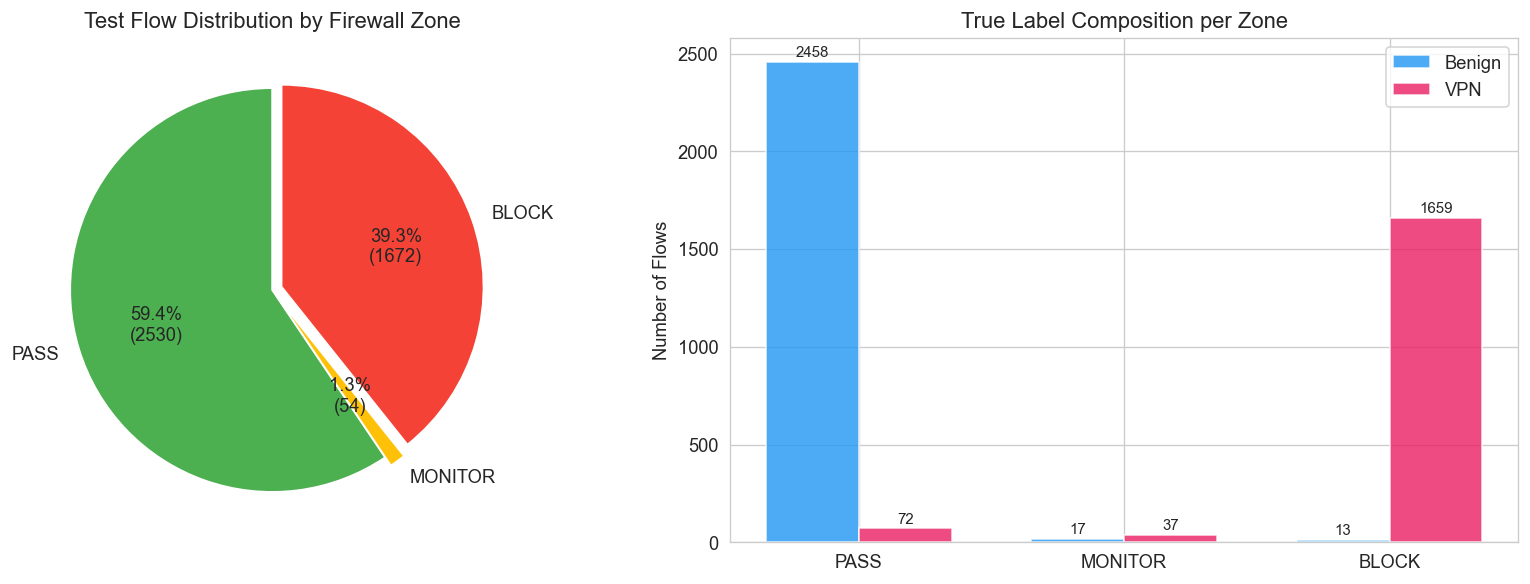

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Pie chart: zone distribution ---
zone_labels = ["PASS", "MONITOR", "BLOCK"]
zone_sizes  = [zc["pass"], zc["monitor"], zc["block"]]
zone_colors = ["#4CAF50", "#FFC107", "#F44336"]
zone_explode = (0, 0.05, 0.05)

wedges, texts, autotexts = ax1.pie(
    zone_sizes, labels=zone_labels, colors=zone_colors,
    explode=zone_explode, autopct=lambda p: f'{p:.1f}%\n({int(p*n_test/100)})',
    startangle=90, textprops={"fontsize": 11}
)
ax1.set_title("Test Flow Distribution by Firewall Zone")

# --- Stacked bar: true label composition per zone ---
pass_mask    = p_test < T_monitor
monitor_mask = (p_test >= T_monitor) & (p_test < T_block)
block_mask   = p_test >= T_block

zones_data = {
    "PASS":    (pass_mask, "#4CAF50"),
    "MONITOR": (monitor_mask, "#FFC107"),
    "BLOCK":   (block_mask, "#F44336"),
}

zone_names = []
vpn_counts = []
ben_counts = []
for name, (mask, _) in zones_data.items():
    zone_names.append(name)
    vpn_counts.append(int((mask & (y_test == 1)).sum()))
    ben_counts.append(int((mask & (y_test == 0)).sum()))

x = np.arange(len(zone_names))
w = 0.35
bars1 = ax2.bar(x - w/2, ben_counts, w, label="Benign", color="#2196F3", alpha=0.8)
bars2 = ax2.bar(x + w/2, vpn_counts, w, label="VPN",    color="#E91E63", alpha=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels(zone_names)
ax2.set_ylabel("Number of Flows")
ax2.set_title("True Label Composition per Zone")
ax2.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax2.annotate(f'{int(h)}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Per-Dataset Breakdown

How does the firewall perform on each dataset individually?

Note: USBVPN test split may be single-class (all VPN or all non-VPN) in the
clean pipeline's capture-based split, so it may be skipped.

dataset,n_flows,n_pos,n_neg,roc_auc,pr_auc,brier,ece,false_block_rate,missed_vpn_rate,alert_zone_fraction,block_precision,block_recall
iscx,1772,444,1328,0.979500,0.969000,0.033300,0.045600,0.001500,0.184700,0.018600,0.994500,0.815300
vnat,1215,55,1160,0.998800,0.956100,0.009900,0.024600,0.009500,0.036400,0.009900,0.828100,0.963600


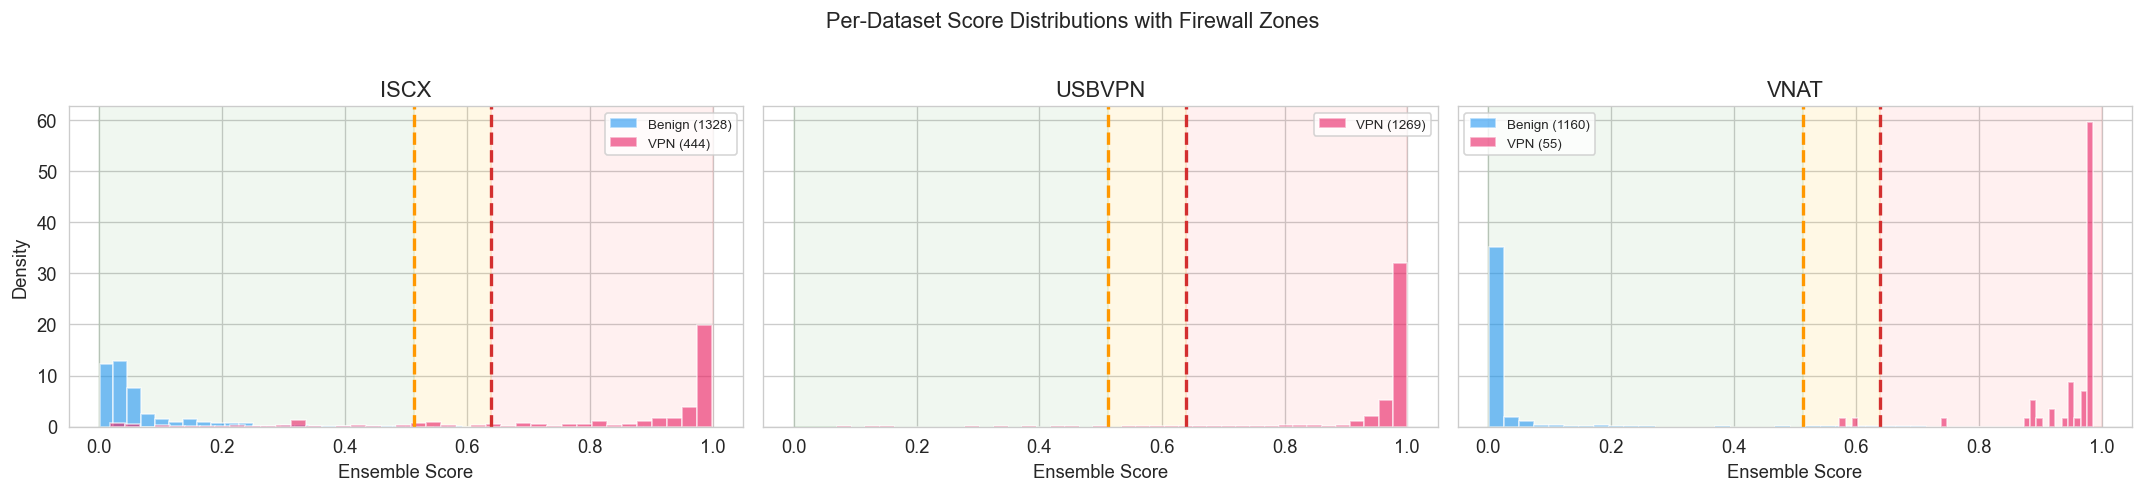

In [8]:
if DS_CSV.exists():
    ds_df = pd.read_csv(DS_CSV)
    display(ds_df.round(4).style.set_caption("Per-Dataset Firewall Metrics").hide(axis='index'))
else:
    print("Per-dataset CSV not found.")

# Per-dataset score distributions
datasets = sorted(test_df["dataset"].unique())
fig, axes = plt.subplots(1, len(datasets), figsize=(6*len(datasets), 4), sharey=True)
if len(datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    ds_mask = test_df["dataset"].values == ds
    ds_ben = p_test[(ds_mask) & (y_test == 0)]
    ds_vpn = p_test[(ds_mask) & (y_test == 1)]

    ax.axvspan(0, T_monitor, alpha=0.06, color="green")
    ax.axvspan(T_monitor, T_block, alpha=0.10, color="#FFC107")
    ax.axvspan(T_block, 1.0, alpha=0.06, color="red")

    if len(ds_ben) > 0:
        ax.hist(ds_ben, bins=40, alpha=0.6, density=True, color="#2196F3", label=f"Benign ({len(ds_ben)})")
    if len(ds_vpn) > 0:
        ax.hist(ds_vpn, bins=40, alpha=0.6, density=True, color="#E91E63", label=f"VPN ({len(ds_vpn)})")

    ax.axvline(T_block, color="#D32F2F", linestyle="--", linewidth=2)
    ax.axvline(T_monitor, color="#FF9800", linestyle="--", linewidth=2)
    ax.set_title(f"{ds.upper()}")
    ax.set_xlabel("Ensemble Score")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Density")
plt.suptitle("Per-Dataset Score Distributions with Firewall Zones", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Calibration Reliability Diagram

Shows how well the predicted probabilities match actual VPN rates.
A perfectly calibrated model follows the diagonal.

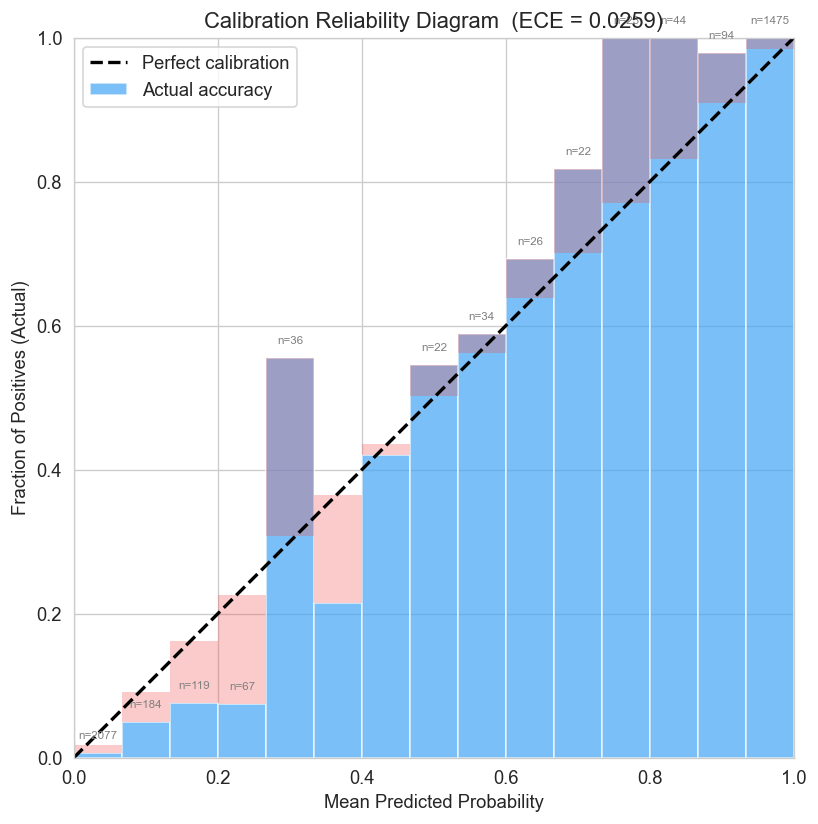

In [9]:
ece_data = expected_calibration_error(y_test, p_test, n_bins=15)

fig, ax = plt.subplots(figsize=(7, 7))

bin_edges = ece_data["bin_edges"]
bin_accs  = ece_data["bin_accs"]
bin_confs = ece_data["bin_confs"]
bin_counts = ece_data["bin_counts"]

# Bar widths
widths = [bin_edges[i+1] - bin_edges[i] for i in range(len(bin_accs))]
lefts  = [bin_edges[i] for i in range(len(bin_accs))]

# Accuracy bars
bars = ax.bar(lefts, bin_accs, width=widths, align="edge", alpha=0.7,
              color="#42A5F5", edgecolor="white", label="Actual accuracy")

# Gap bars (calibration error)
for i in range(len(bin_accs)):
    if bin_counts[i] > 0:
        gap = abs(bin_accs[i] - bin_confs[i])
        bottom = min(bin_accs[i], bin_confs[i])
        ax.bar(lefts[i], gap, bottom=bottom, width=widths[i], align="edge",
               alpha=0.3, color="#EF5350", edgecolor="none")

# Perfect calibration line
ax.plot([0, 1], [0, 1], "k--", linewidth=2, label="Perfect calibration")

# Annotations
for i in range(len(bin_accs)):
    if bin_counts[i] > 20:
        ax.text(lefts[i] + widths[i]/2, bin_accs[i] + 0.02,
                f'n={bin_counts[i]}', ha="center", fontsize=7, color="gray")

ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives (Actual)")
ax.set_title(f"Calibration Reliability Diagram  (ECE = {ece_data['ece']:.4f})")
ax.legend(loc="upper left")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 9. Threshold Sensitivity Analysis

How do false_block_rate and missed_vpn_rate change as we vary T_block?

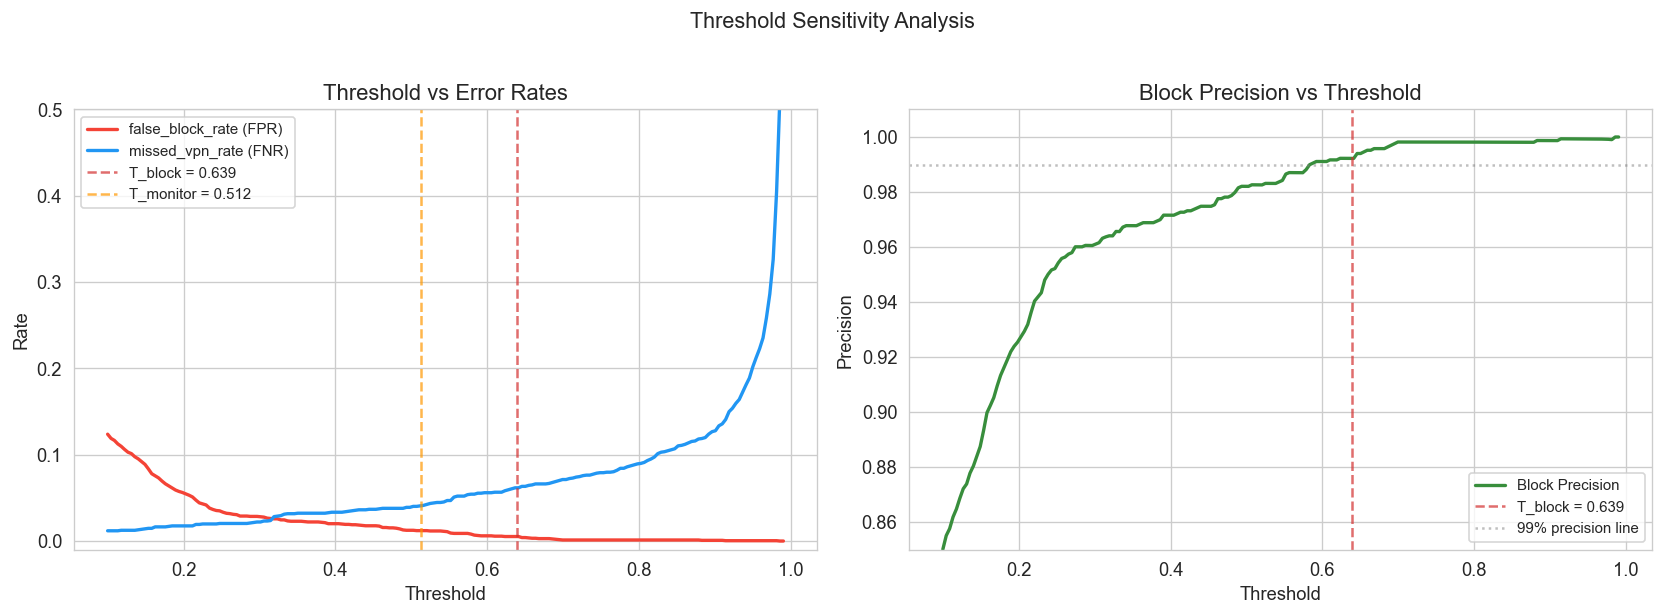

In [10]:
thresholds = np.linspace(0.1, 0.99, 200)
fbr_list = []
mvr_list = []
block_prec_list = []

for thr in thresholds:
    pred = (p_test >= thr).astype(int)
    fp = ((pred == 1) & (y_test == 0)).sum()
    tn = ((pred == 0) & (y_test == 0)).sum()
    tp = ((pred == 1) & (y_test == 1)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()

    fbr = fp / max(fp + tn, 1)
    mvr = fn / max(fn + tp, 1)
    prec = tp / max(tp + fp, 1)

    fbr_list.append(fbr)
    mvr_list.append(mvr)
    block_prec_list.append(prec)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: FBR vs MVR trade-off
ax1.plot(thresholds, fbr_list, color="#F44336", linewidth=2, label="false_block_rate (FPR)")
ax1.plot(thresholds, mvr_list, color="#2196F3", linewidth=2, label="missed_vpn_rate (FNR)")
ax1.axvline(T_block, color="#D32F2F", linestyle="--", alpha=0.7, label=f"T_block = {T_block:.3f}")
ax1.axvline(T_monitor, color="#FF9800", linestyle="--", alpha=0.7, label=f"T_monitor = {T_monitor:.3f}")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Rate")
ax1.set_title("Threshold vs Error Rates")
ax1.legend(fontsize=9)
ax1.set_ylim(-0.01, 0.5)

# Right: Block precision vs threshold
ax2.plot(thresholds, block_prec_list, color="#388E3C", linewidth=2, label="Block Precision")
ax2.axvline(T_block, color="#D32F2F", linestyle="--", alpha=0.7, label=f"T_block = {T_block:.3f}")
ax2.axhline(0.99, color="gray", linestyle=":", alpha=0.5, label="99% precision line")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Precision")
ax2.set_title("Block Precision vs Threshold")
ax2.legend(fontsize=9)
ax2.set_ylim(0.85, 1.01)

plt.suptitle("Threshold Sensitivity Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Per-Model Score Comparison (XGB vs LGB vs CB)

How do the three individual model scores compare to the ensemble?

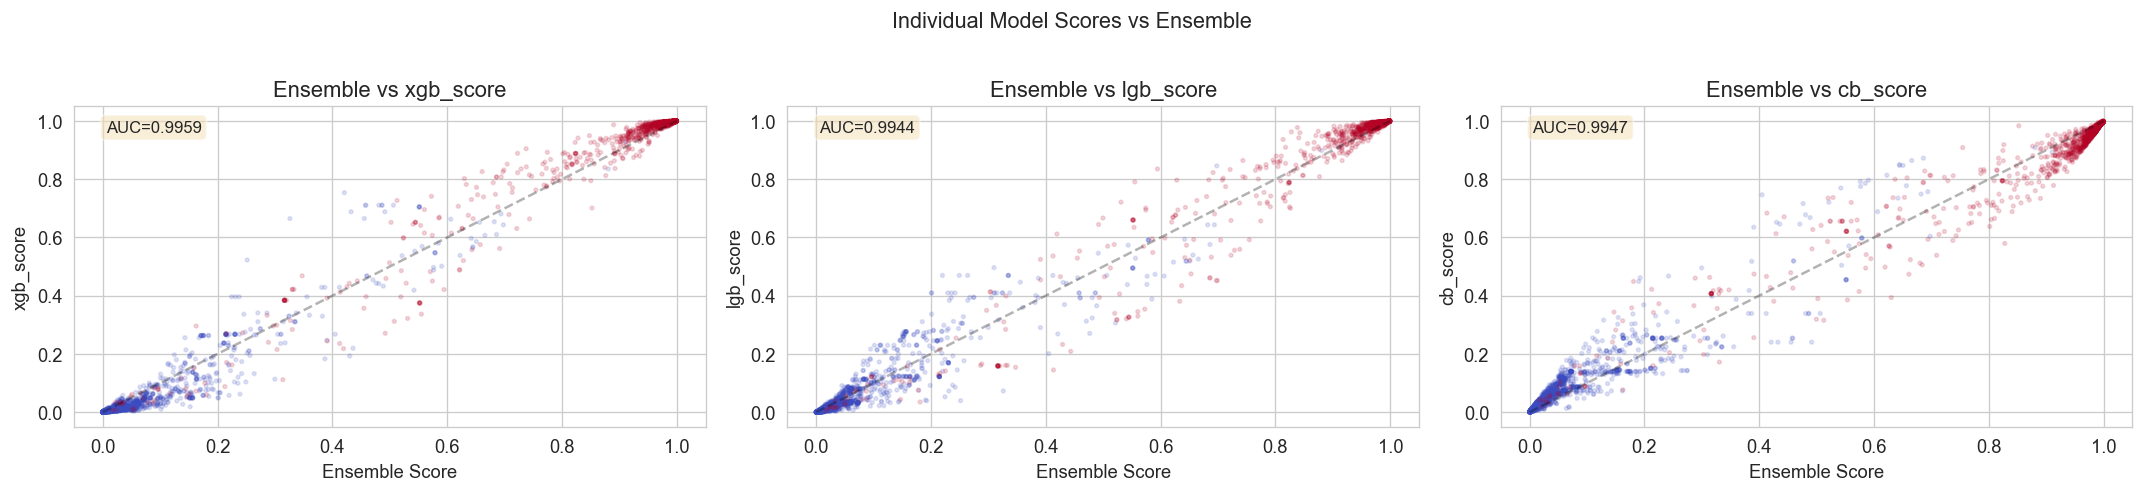

In [11]:
model_cols = [c for c in test_df.columns if c.endswith("_score") and c != "ensemble_score"]
if model_cols:
    fig, axes = plt.subplots(1, len(model_cols), figsize=(6*len(model_cols), 4))
    if len(model_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, model_cols):
        ax.scatter(test_df["ensemble_score"], test_df[col], alpha=0.15, s=5,
                   c=y_test, cmap="coolwarm")
        ax.plot([0,1],[0,1], "k--", alpha=0.3)
        ax.set_xlabel("Ensemble Score")
        ax.set_ylabel(col)
        ax.set_title(f"Ensemble vs {col}")

        auc = roc_auc_score(y_test, test_df[col].values)
        ax.text(0.05, 0.92, f"AUC={auc:.4f}", transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    plt.suptitle("Individual Model Scores vs Ensemble", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No individual model score columns found.")

## 11. Training Loss Curves (XGBoost / LightGBM / CatBoost)

Validation log-loss per boosting round for each model.
CatBoost also provides training loss, allowing a train-vs-validation comparison.

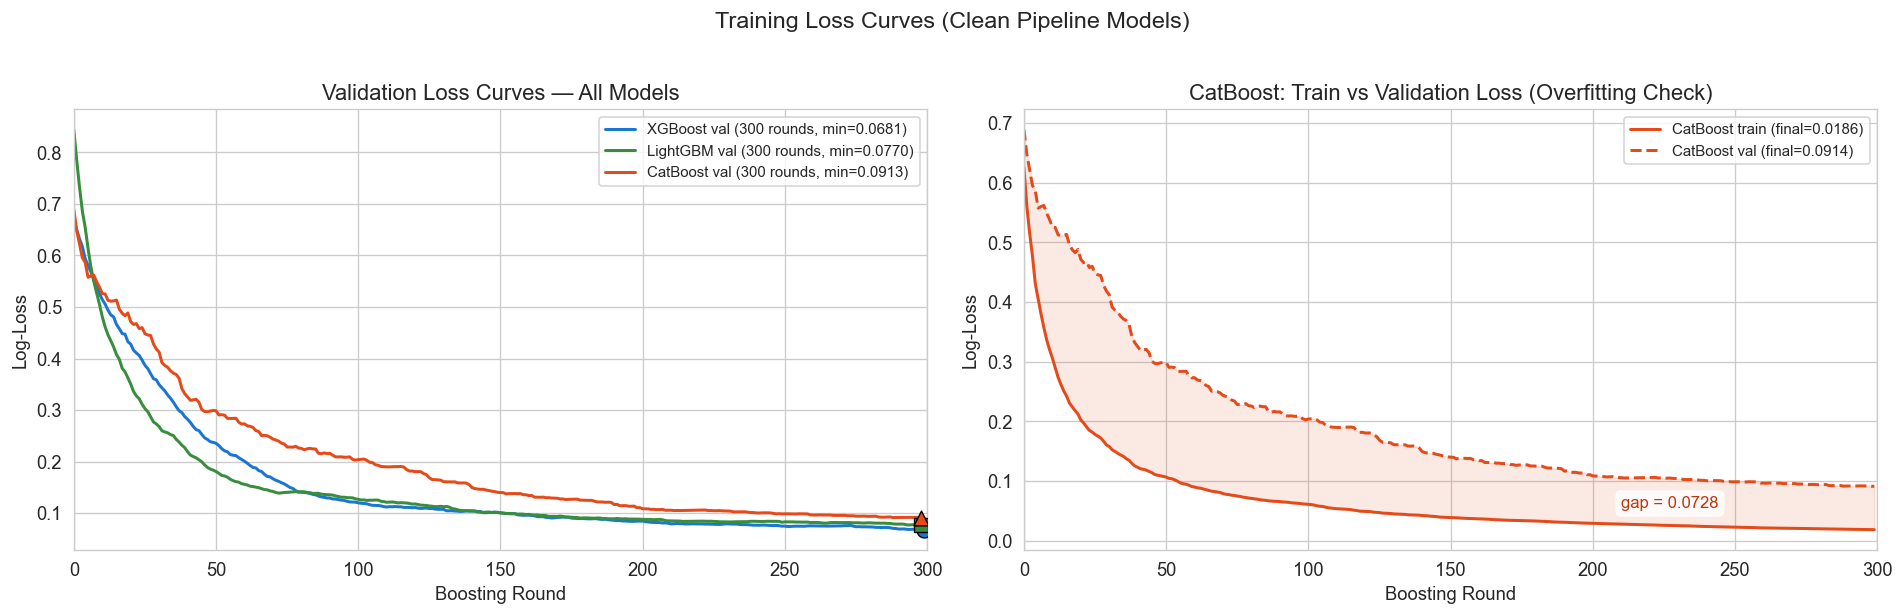

XGBoost  — 300 rounds, best val logloss = 0.068100 (round 299)
LightGBM — 300 rounds, best val logloss = 0.077014 (round 298)
CatBoost — 300 rounds, best val logloss = 0.091269 (round 298)

CatBoost train-val gap at final round: 0.072808 — notable overfitting


In [12]:
# --- Load saved models to extract training history ---
MODEL_DIR = CLEAN / "models"

xgb_model = pickle.load(open(MODEL_DIR / "xgb_model.pkl", "rb"))
lgb_model = pickle.load(open(MODEL_DIR / "lgb_model.pkl", "rb"))
cb_model  = pickle.load(open(MODEL_DIR / "cb_model.pkl", "rb"))

# Extract validation logloss per round
xgb_val_loss = xgb_model.evals_result_["validation_0"]["logloss"]
lgb_val_loss = lgb_model.evals_result_["valid_0"]["binary_logloss"]
cb_evals     = cb_model.get_evals_result()
cb_train_loss = cb_evals["learn"]["Logloss"]
cb_val_loss   = cb_evals["validation"]["Logloss"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: All models – validation loss ---
ax1.plot(range(len(xgb_val_loss)), xgb_val_loss, color="#1976D2", linewidth=1.8,
         label=f"XGBoost val ({len(xgb_val_loss)} rounds, min={min(xgb_val_loss):.4f})")
ax1.plot(range(len(lgb_val_loss)), lgb_val_loss, color="#388E3C", linewidth=1.8,
         label=f"LightGBM val ({len(lgb_val_loss)} rounds, min={min(lgb_val_loss):.4f})")
ax1.plot(range(len(cb_val_loss)), cb_val_loss, color="#E64A19", linewidth=1.8,
         label=f"CatBoost val ({len(cb_val_loss)} rounds, min={min(cb_val_loss):.4f})")

# Mark minimum points
for loss, color, marker in [
    (xgb_val_loss, "#1976D2", "o"),
    (lgb_val_loss, "#388E3C", "s"),
    (cb_val_loss, "#E64A19", "^"),
]:
    min_idx = int(np.argmin(loss))
    ax1.scatter(min_idx, loss[min_idx], c=color, s=80, zorder=5, marker=marker,
                edgecolors="black", linewidths=0.8)

ax1.set_xlabel("Boosting Round")
ax1.set_ylabel("Log-Loss")
ax1.set_title("Validation Loss Curves — All Models")
ax1.legend(fontsize=9)
ax1.set_xlim(0, max(len(xgb_val_loss), len(lgb_val_loss), len(cb_val_loss)))

# --- Right: CatBoost train vs val (overfitting diagnostic) ---
ax2.plot(range(len(cb_train_loss)), cb_train_loss, color="#E64A19", linewidth=1.8,
         linestyle="-", label=f"CatBoost train (final={cb_train_loss[-1]:.4f})")
ax2.plot(range(len(cb_val_loss)), cb_val_loss, color="#E64A19", linewidth=1.8,
         linestyle="--", label=f"CatBoost val (final={cb_val_loss[-1]:.4f})")

gap = cb_val_loss[-1] - cb_train_loss[-1]
ax2.fill_between(range(len(cb_train_loss)), cb_train_loss, cb_val_loss,
                 alpha=0.12, color="#E64A19")
ax2.annotate(f"gap = {gap:.4f}", xy=(len(cb_val_loss)*0.7, (cb_train_loss[-1]+cb_val_loss[-1])/2),
             fontsize=10, color="#BF360C",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax2.set_xlabel("Boosting Round")
ax2.set_ylabel("Log-Loss")
ax2.set_title("CatBoost: Train vs Validation Loss (Overfitting Check)")
ax2.legend(fontsize=9)
ax2.set_xlim(0, len(cb_train_loss))

plt.suptitle("Training Loss Curves (Clean Pipeline Models)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
print(f"XGBoost  — {len(xgb_val_loss):>3} rounds, best val logloss = {min(xgb_val_loss):.6f} (round {int(np.argmin(xgb_val_loss))})")
print(f"LightGBM — {len(lgb_val_loss):>3} rounds, best val logloss = {min(lgb_val_loss):.6f} (round {int(np.argmin(lgb_val_loss))})")
print(f"CatBoost — {len(cb_val_loss):>3} rounds, best val logloss = {min(cb_val_loss):.6f} (round {int(np.argmin(cb_val_loss))})")
print(f"\nCatBoost train-val gap at final round: {gap:.6f}",
      "— minimal overfitting" if gap < 0.02 else "— moderate overfitting" if gap < 0.05 else "— notable overfitting")

## 12. Summary & Verdict

In [13]:
print("=" * 60)
print("  FIREWALL DECISION MODULE — SUMMARY")
print("=" * 60)
print()

cm = results["core_metrics"]
fe = results["firewall_evaluation"]
fw = results["firewall_thresholds"]

print(f"  Source:      {results.get('source', 'clean_pipeline')}")
print(f"  Features:    {results.get('n_features', '?')} ({results.get('feature_family', '?')})")
print(f"  Test flows:  {results['data_info']['n_test']:,}")
print()
print(f"  ROC-AUC:     {cm['roc_auc']:.4f}")
print(f"  PR-AUC:      {cm['pr_auc']:.4f}")
print(f"  ECE:         {cm['ece']:.4f} ({cm['calibration_quality']})")
print()
print(f"  T_block:     {fw['T_block']:.4f}")
print(f"  T_monitor:   {fw['T_monitor']:.4f}")
print()
print(f"  Block precision: {fe['block_precision']:.4f}")
print(f"  Block recall:    {fe['block_recall']:.4f}")
print(f"  Block F1:        {fe['block_f1']:.4f}")
print()
print(f"  false_block_rate:    {fe['false_block_rate']:.4f} ({fe['block_confusion']['fp']} benign flows wrongly blocked)")
print(f"  missed_vpn_rate:     {fe['missed_vpn_rate']:.4f} ({fe['block_confusion']['fn']} VPN flows not blocked)")
print(f"  alert_zone_fraction: {fe['alert_zone_fraction']:.4f} ({fe['zone_counts']['monitor']} flows for analyst review)")
print()

# Verdict
if fe["block_precision"] >= 0.99 and fe["missed_vpn_rate"] < 0.10:
    verdict = "EXCELLENT — high precision, low miss rate"
elif fe["block_precision"] >= 0.95 and fe["missed_vpn_rate"] < 0.15:
    verdict = "GOOD — suitable for monitored deployment"
elif fe["block_precision"] >= 0.90:
    verdict = "ACCEPTABLE — requires tuning for production"
else:
    verdict = "NEEDS IMPROVEMENT"
print(f"  VERDICT: {verdict}")
print()

  FIREWALL DECISION MODULE — SUMMARY

  Source:      clean_pipeline (NB41-55)
  Features:    25 (safe_temporal_21 / direction_invariant_augmented)
  Test flows:  4,256

  ROC-AUC:     0.9955
  PR-AUC:      0.9949
  ECE:         0.0259 (well-calibrated)

  T_block:     0.6392
  T_monitor:   0.5122

  Block precision: 0.9922
  Block recall:    0.9383
  Block F1:        0.9645

  false_block_rate:    0.0052 (13 benign flows wrongly blocked)
  missed_vpn_rate:     0.0617 (109 VPN flows not blocked)
  alert_zone_fraction: 0.0127 (54 flows for analyst review)

  VERDICT: EXCELLENT — high precision, low miss rate



---

**End of Notebook 56.**

All metrics sourced from the clean pipeline (NB41-55) ensemble predictions.  
Exported artifacts in `artifacts/eval/firewall_operating_points.{csv,json}`.

---
## Results Gallery — All Figures & Tables (NB56)

Display every `.png` figure and `.csv` table generated by this notebook.

In [ ]:
# ── Results Gallery: NB56 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "thesis_finalization" / "nb56_firewall_decision_eval"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

display(Markdown(f'# \U0001f4ca NB56 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {{_p.stem.replace("_", " ").title()}}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {{_c.stem.replace("_", " ").title()}}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {{_j.stem.replace("_", " ").title()}}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB56 gallery complete.')
